# House Price Prediction Regressio  Project

## 1. Import Libraries

In [117]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load Dataset

In [118]:
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [119]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Data Exploration

### Display First 10 Rows

In [120]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### Check Dataset Shape

In [121]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 545
Columns: 13


### Column Names

In [122]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

### Target and Features

In [123]:
target = "price"

features = df.columns.drop(target)

print("Target Variable:", target)
print("Features:")
print(features)

Target Variable: price
Features:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


### Dataset Information

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### Missing Values

In [125]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


### Statistical Summary

In [126]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 4. Data Cleaning

### Check Duplicates

In [127]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Remove Duplicates

In [128]:
df = df.drop_duplicates()

### Check Data Types

In [129]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


## 5. Convert Categorical Columns

### Categorical Columns:

In [130]:
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


### One-Hot Encoding

In [131]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


## 6. Feature Selection

In [132]:
X = df_encoded.drop("price", axis=1)

y = df_encoded["price"]

## 7. Train-Test Split

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### Check Shapes

In [134]:
print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


## 8. Linear Regression Model

In [135]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

### Predictions

In [136]:
lr_pred = lr_model.predict(X_test)

### Evaluation

In [137]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Results
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


## 9. Random Forest Regressor

In [138]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

### Predictions

In [139]:
rf_pred = rf_model.predict(X_test)

### Evaluation

In [140]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE : 1013968.579587156
RMSE: 1398115.6668385956
R² Score: 0.6132752494107068


## 10. Model Comparison

In [141]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


## Visualization 1: House Price Distribution

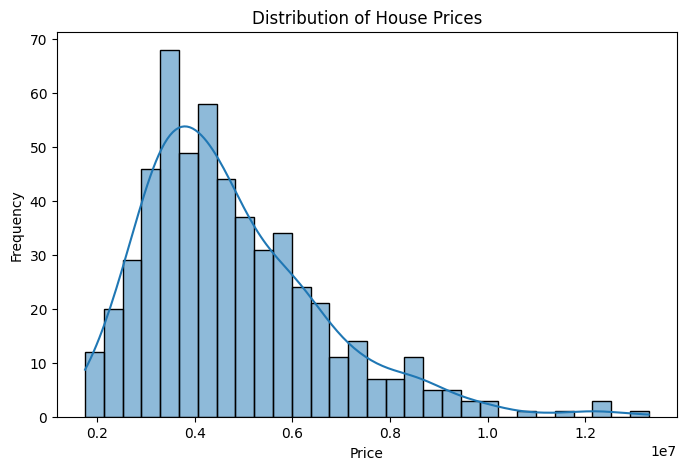

In [142]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

## Visualization 2: Correlation Heatmap

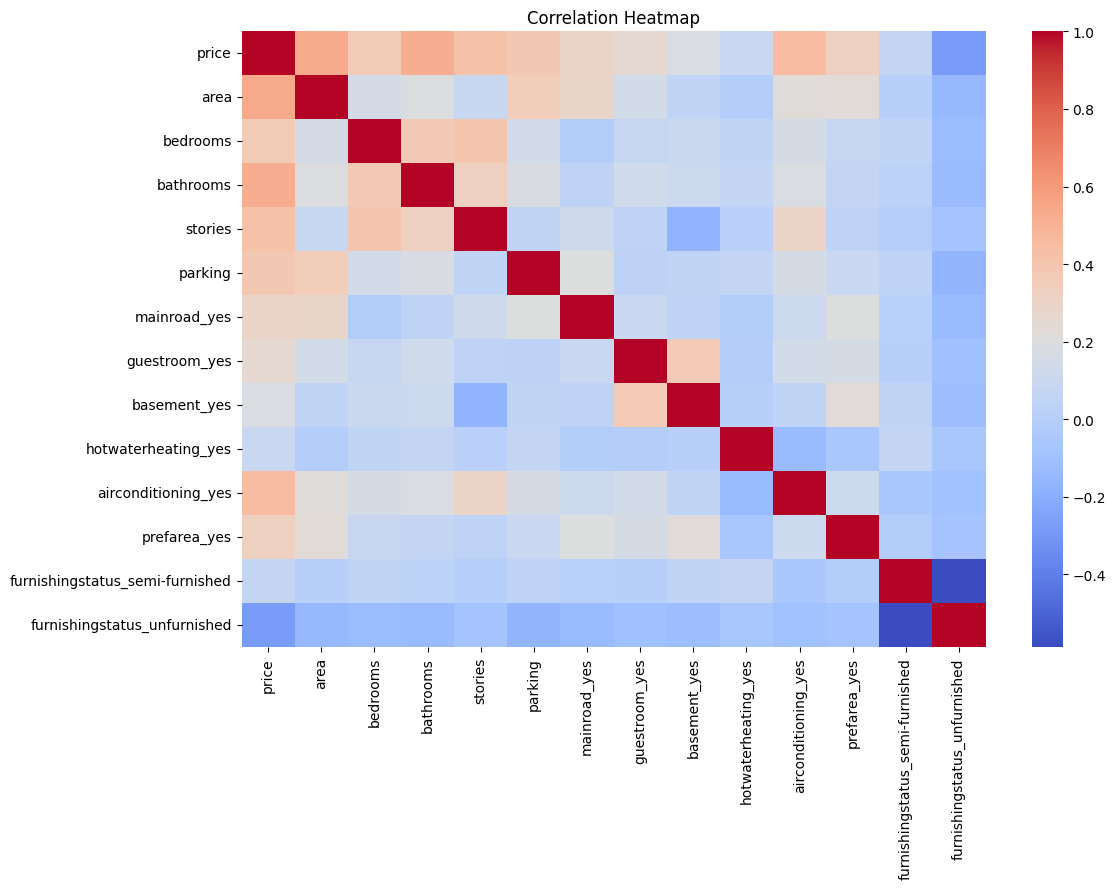

In [143]:
plt.figure(figsize=(12,8))

corr = df_encoded.corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Visualization 3: Actual vs Predicted Prices

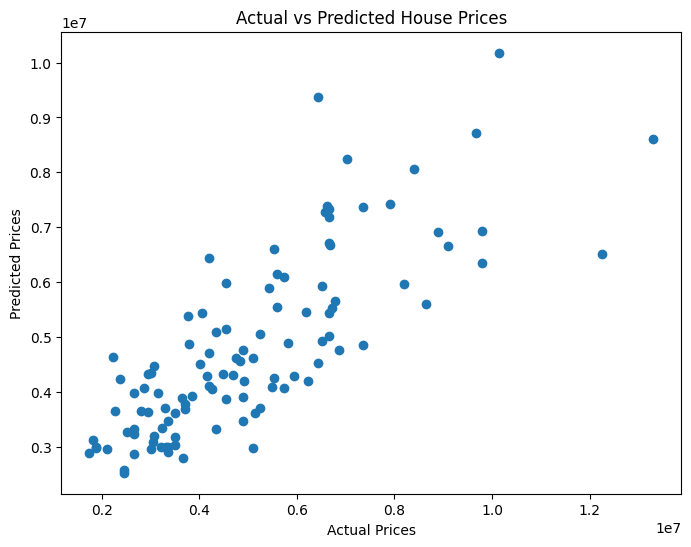

In [144]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

## 11. Feature Importance

In [145]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468535
2,bathrooms,0.152554
9,airconditioning_yes,0.060238
4,parking,0.057273
3,stories,0.057064
1,bedrooms,0.047370
12,furnishingstatus_unfurnished,0.036972
7,basement_yes,0.032176
10,prefarea_yes,0.028432
8,hotwaterheating_yes,0.018305


### Plot Feature Importance

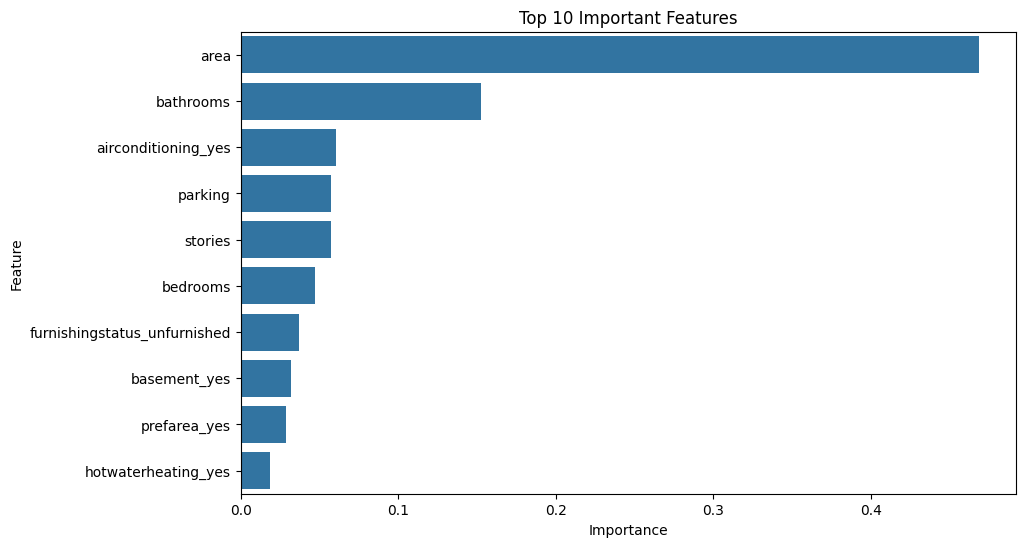

In [146]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

## Insights & Summary

Based on the analysis, the most influential features affecting house prices were property area, number of bathrooms, number of stories, parking availability, and location-related attributes. The Random Forest model performed better than Linear Regression, indicating that it captured more complex relationships within the housing data. In simple terms, the model was able to predict house prices with good accuracy and can be used as a reliable pricing tool. One surprising finding was that features such as parking availability and furnishing status had a noticeable impact on house prices. The analysis also confirmed that larger properties generally have higher market values. Based on these findings, real estate businesses should focus on properties with larger areas, better amenities, and desirable locations to maximize value and demand.